# 📊 EduHestim — Analyse de Données
### Intégration de l'Analyse de Données dans la Plateforme de Gestion des Emplois du Temps et Réservation des Salles
---
## 🎯 3 axes d'analyse
| # | Axe | Table(s) | Colonnes clés |
|---|-----|----------|---------------|
| 1 | **Taux d'occupation des salles** | `Salles` + `Reservations` | `ID_Salle`, `Nom_Salle`, `Type_Salle`, `Capacite`, `Batiment`, `Statut`, `Heure_Debut`, `Jour_Semaine` |
| 2 | **Volume horaire enseignant** | `Enseignants` + `EmploiDuTemps` | `ID_Enseignant`, `Nom`, `Prenom`, `Departement`, `Grade`, `Heure_Debut`, `Heure_Fin`, `Statut` |
| 3 | **Taux de conflits** | `Conflits` | `Type_Conflit`, `Resolu`, `Jour_Semaine`, `Heure_Debut` |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

BLUE='#003d82'; RED='#c1002a'; GREEN='#2e7d32'; ORANGE='#ff8f00'; PURPLE='#7b1fa2'
COLORS=[BLUE,RED,GREEN,ORANGE,PURPLE,'#00796b']
plt.rcParams['figure.figsize']=(13,5)
plt.rcParams['font.family']='DejaVu Sans'
plt.rcParams['axes.spines.top']=False
plt.rcParams['axes.spines.right']=False
print('OK imports')

OK imports


In [2]:
FILE='eduhestim_dataset.xlsx'
df_salles=pd.read_excel(FILE,sheet_name='Salles')
df_resa  =pd.read_excel(FILE,sheet_name='Reservations')
df_ens   =pd.read_excel(FILE,sheet_name='Enseignants')
df_edt   =pd.read_excel(FILE,sheet_name='EmploiDuTemps')
df_conf  =pd.read_excel(FILE,sheet_name='Conflits')
print('Tables chargees')
for n,d in [('Salles',df_salles),('Reservations',df_resa),('Enseignants',df_ens),('EmploiDuTemps',df_edt),('Conflits',df_conf)]:
    print(f'  {n:15s}: {d.shape[0]} lignes x {d.shape[1]} colonnes')

Tables chargees
  Salles         : 125 lignes x 8 colonnes
  Reservations   : 8534 lignes x 17 colonnes
  Enseignants    : 40 lignes x 12 colonnes
  EmploiDuTemps  : 600 lignes x 15 colonnes
  Conflits       : 80 lignes x 12 colonnes


In [3]:
df_conf['Resolu']=df_conf['Resolu'].astype(bool)

def duree_h(debut,fin):
    try:
        h1=int(str(debut).split(':')[0])
        h2=int(str(fin).split(':')[0])
        return max(h2-h1,2)
    except:
        return 2

df_edt['Duree_H']=df_edt.apply(lambda r:duree_h(r['Heure_Debut'],r['Heure_Fin']),axis=1)
print('Nettoyage OK')
print('Valeurs manquantes par table:')
for n,d in [('Salles',df_salles),('Reservations',df_resa),('Enseignants',df_ens),('EmploiDuTemps',df_edt),('Conflits',df_conf)]:
    print(f'  {n:15s}: {d.isnull().sum().sum()} NaN')

Nettoyage OK
Valeurs manquantes par table:
  Salles         : 0 NaN
  Reservations   : 4252 NaN
  Enseignants    : 0 NaN
  EmploiDuTemps  : 0 NaN
  Conflits       : 50 NaN


---
# 🏫 AXE 1 — Taux d'Occupation des Salles
**Formule :** `Taux = (Nb réservations approuvées / 640 créneaux possibles) x 100`
> 640 = 5 jours x 4 créneaux x 32 semaines

In [4]:
TOTAL_CRENEAUX=640
resa_ok=df_resa[df_resa['Statut']=='approuve']
nb_resa=resa_ok.groupby('ID_Salle').size().reset_index(name='Nb_Resa')
df_occ=df_salles.drop(columns=['Nb_Reservations','Taux_Occupation'],errors='ignore').merge(
    nb_resa,on='ID_Salle',how='left').fillna({'Nb_Resa':0})
df_occ['Taux_Occupation']=(df_occ['Nb_Resa']/TOTAL_CRENEAUX*100).round(1)
moy_occ=df_occ['Taux_Occupation'].mean()
print('=== TAUX OCCUPATION SALLES ===')
print(df_occ['Taux_Occupation'].describe().round(2))
print(f'\nSalle la + occupee  : {df_occ.loc[df_occ["Taux_Occupation"].idxmax(),"Nom_Salle"]} ({df_occ["Taux_Occupation"].max():.1f}%)')
print(f'Taux moyen global   : {moy_occ:.1f}%')

=== TAUX OCCUPATION SALLES ===
count    125.00
mean       6.44
std        2.74
min        1.20
25%        3.60
50%        6.60
75%        8.40
max       11.60
Name: Taux_Occupation, dtype: float64

Salle la + occupee  : Norm-54 (11.6%)
Taux moyen global   : 6.4%


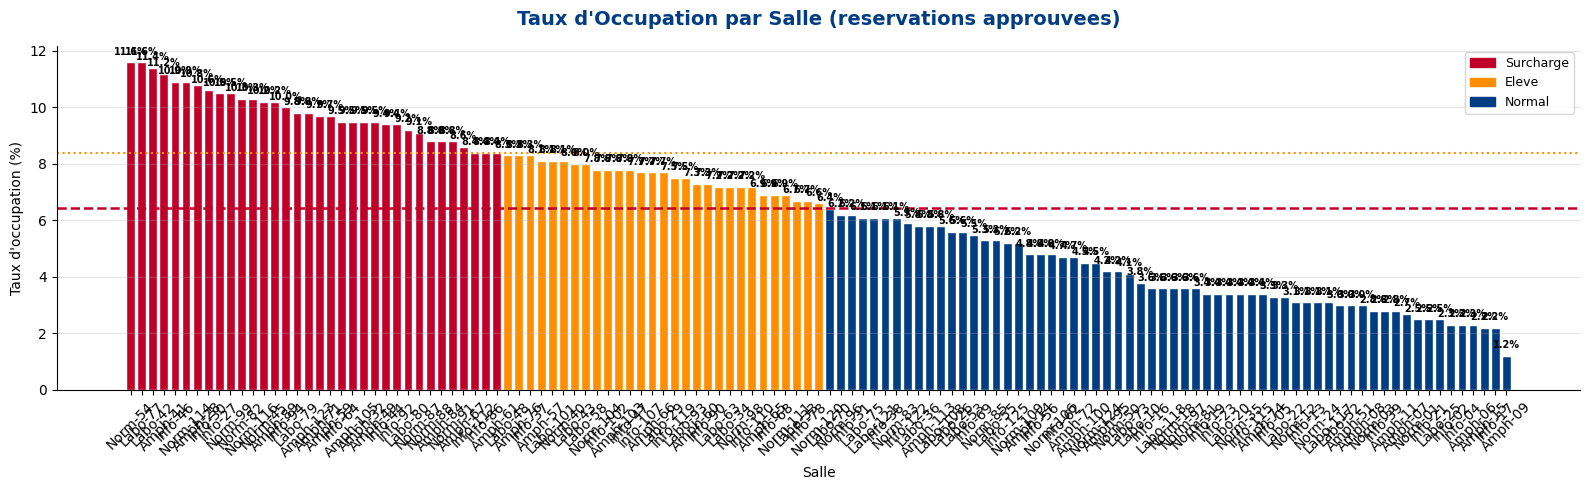

Sauvegarde: ax1_occupation.png


In [5]:
df_occ_s=df_occ.sort_values('Taux_Occupation',ascending=False)
seuil_occ=moy_occ*1.3
bar_colors=[RED if v>=seuil_occ else(ORANGE if v>=moy_occ else BLUE) for v in df_occ_s['Taux_Occupation']]

fig,ax=plt.subplots(figsize=(16,5))
bars=ax.bar(df_occ_s['Nom_Salle'],df_occ_s['Taux_Occupation'],color=bar_colors,edgecolor='white')
ax.axhline(moy_occ,color=RED,linestyle='--',linewidth=1.8,label=f'Moyenne: {moy_occ:.1f}%')
ax.axhline(seuil_occ,color=ORANGE,linestyle=':',linewidth=1.5,label=f'Seuil surcharge: {seuil_occ:.1f}%')
for bar in bars:
    if bar.get_height()>0:
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.2,
                f'{bar.get_height():.1f}%',ha='center',va='bottom',fontsize=7,fontweight='bold')
legend_p=[mpatches.Patch(color=RED,label='Surcharge'),mpatches.Patch(color=ORANGE,label='Eleve'),mpatches.Patch(color=BLUE,label='Normal')]
ax.legend(handles=legend_p,fontsize=9)
ax.set_title("Taux d'Occupation par Salle (reservations approuvees)",fontsize=14,fontweight='bold',color=BLUE,pad=15)
ax.set_xlabel('Salle'); ax.set_ylabel("Taux d'occupation (%)")
ax.tick_params(axis='x',rotation=45); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig('ax1_occupation.png',dpi=150,bbox_inches='tight'); plt.show()
print('Sauvegarde: ax1_occupation.png')

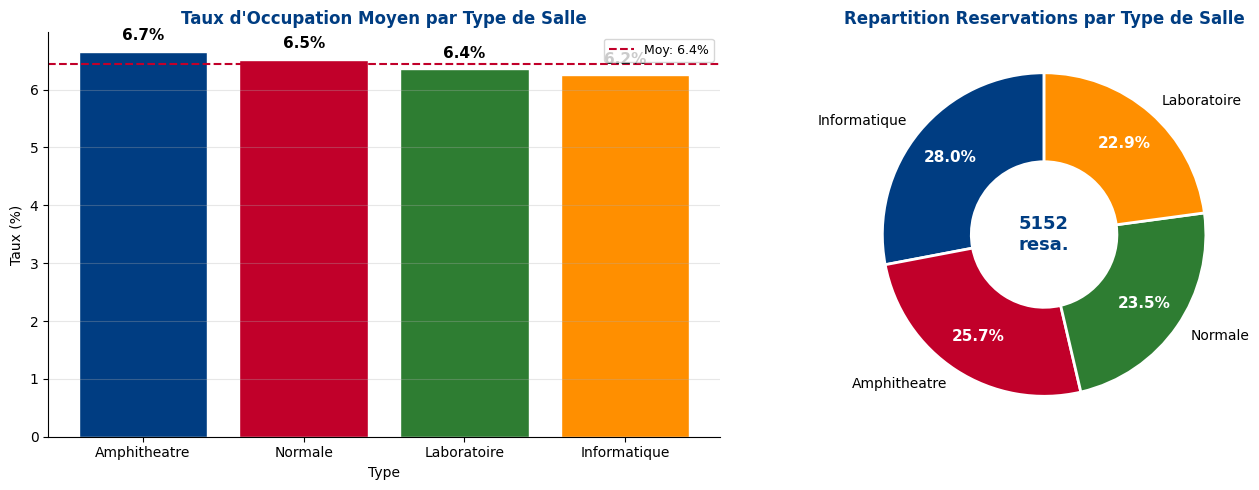

Sauvegarde: ax1_type_salle.png


In [6]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
type_occ=df_occ.groupby('Type_Salle')['Taux_Occupation'].mean().sort_values(ascending=False)
axes[0].bar(type_occ.index,type_occ.values,color=COLORS[:len(type_occ)],edgecolor='white')
for i,v in enumerate(type_occ.values):
    axes[0].text(i,v+0.2,f'{v:.1f}%',ha='center',fontweight='bold',fontsize=11)
axes[0].axhline(type_occ.mean(),color=RED,linestyle='--',linewidth=1.5,label=f'Moy: {type_occ.mean():.1f}%')
axes[0].set_title("Taux d'Occupation Moyen par Type de Salle",fontsize=12,fontweight='bold',color=BLUE)
axes[0].set_xlabel('Type'); axes[0].set_ylabel('Taux (%)'); axes[0].legend(fontsize=9); axes[0].grid(axis='y',alpha=0.3)

resa_type=resa_ok.merge(df_salles[['ID_Salle','Type_Salle']],on='ID_Salle',how='left')
type_counts=resa_type['Type_Salle'].value_counts()
wedges,texts,autos=axes[1].pie(type_counts.values,labels=type_counts.index,autopct='%1.1f%%',
    colors=COLORS[:len(type_counts)],startangle=90,pctdistance=0.75,
    wedgeprops=dict(width=0.55,edgecolor='white',linewidth=2))
for at in autos: at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
axes[1].text(0,0,f'{type_counts.sum()}\nresa.',ha='center',va='center',fontsize=13,fontweight='bold',color=BLUE)
axes[1].set_title('Repartition Reservations par Type de Salle',fontsize=12,fontweight='bold',color=BLUE)
plt.tight_layout(); plt.savefig('ax1_type_salle.png',dpi=150,bbox_inches='tight'); plt.show()
print('Sauvegarde: ax1_type_salle.png')

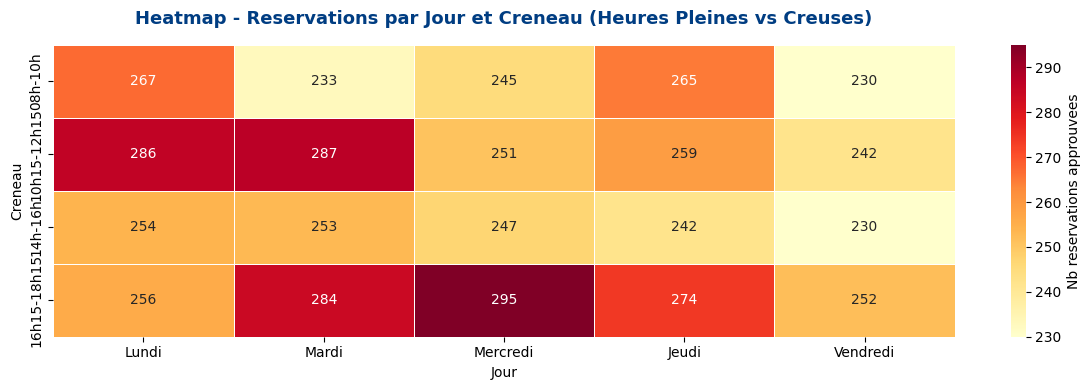

Sauvegarde: ax1_heatmap.png


In [7]:
JOURS_ORDER=['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi']
CRENEAUX_ORDER=['08:00','10:15','14:00','16:15']
LABELS_C={'08:00':'08h-10h','10:15':'10h15-12h15','14:00':'14h-16h','16:15':'16h15-18h15'}

heat_data=resa_ok.groupby(['Jour_Semaine','Heure_Debut']).size().reset_index(name='Nb')
heat_pivot=heat_data.pivot(index='Heure_Debut',columns='Jour_Semaine',values='Nb').fillna(0)
cols_ok=[j for j in JOURS_ORDER if j in heat_pivot.columns]
rows_ok=[c for c in CRENEAUX_ORDER if c in heat_pivot.index]
heat_pivot=heat_pivot.reindex(index=rows_ok,columns=cols_ok)
heat_pivot.index=[LABELS_C.get(i,i) for i in heat_pivot.index]

fig,ax=plt.subplots(figsize=(12,4))
sns.heatmap(heat_pivot,annot=True,fmt='.0f',cmap='YlOrRd',linewidths=0.5,linecolor='white',ax=ax,
    cbar_kws={'label':'Nb reservations approuvees'})
ax.set_title('Heatmap - Reservations par Jour et Creneau (Heures Pleines vs Creuses)',fontsize=13,fontweight='bold',color=BLUE,pad=15)
ax.set_xlabel('Jour'); ax.set_ylabel('Creneau')
plt.tight_layout(); plt.savefig('ax1_heatmap.png',dpi=150,bbox_inches='tight'); plt.show()
print('Sauvegarde: ax1_heatmap.png')

---
# 👨‍🏫 AXE 2 — Volume Horaire Enseignant (Surcharge)
**Formule :** `Volume = Nb seances realisees x 2h` — seuil surcharge = moyenne + 1 ecart-type

In [8]:
edt_actif=df_edt[df_edt['Statut'].isin(['Realise','Planifie'])]
vol_ens=edt_actif.groupby('ID_Enseignant').agg(Nb_Seances=('ID_EDT','count'),Volume_H=('Duree_H','sum')).reset_index()
df_vol=df_ens[['ID_Enseignant','Nom','Prenom','Departement','Grade']].merge(
    vol_ens,on='ID_Enseignant',how='left').fillna({'Nb_Seances':0,'Volume_H':0})
df_vol['Nom_Complet']=df_vol['Prenom'].str[0]+'. '+df_vol['Nom']
moy_vol=df_vol['Volume_H'].mean()
std_vol=df_vol['Volume_H'].std()
seuil=moy_vol+std_vol
df_vol['Surcharge']=df_vol['Volume_H']>seuil
nb_surcharge=int(df_vol['Surcharge'].sum())
print('=== VOLUME HORAIRE ENSEIGNANTS ===')
print(df_vol['Volume_H'].describe().round(2))
print(f'\nMoyenne         : {moy_vol:.1f}h')
print(f'Seuil surcharge : {seuil:.1f}h')
print(f'Nb surcharges   : {nb_surcharge}/{len(df_vol)} ({nb_surcharge/len(df_vol)*100:.1f}%)')

=== VOLUME HORAIRE ENSEIGNANTS ===
count     40.00
mean      25.45
std       33.73
min        0.00
25%        0.00
50%        0.00
75%       51.50
max      126.00
Name: Volume_H, dtype: float64

Moyenne         : 25.4h
Seuil surcharge : 59.2h
Nb surcharges   : 5/40 (12.5%)


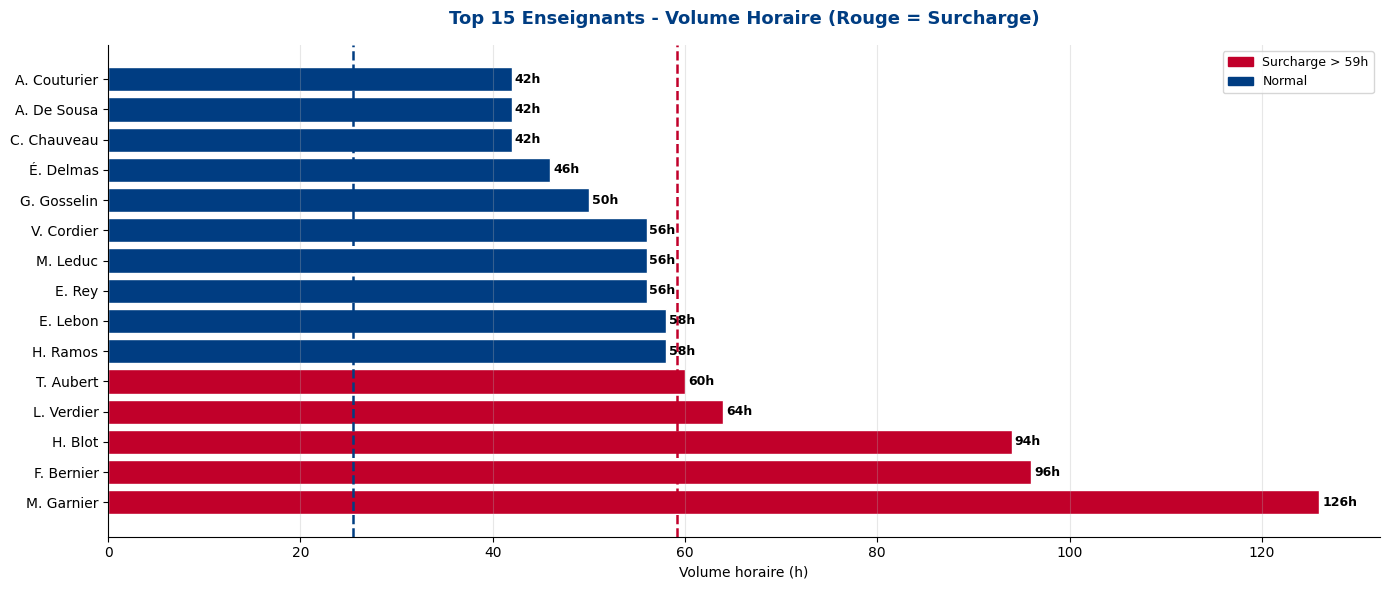

Sauvegarde: ax2_top15.png


In [9]:
top15=df_vol.nlargest(15,'Volume_H')
fig,ax=plt.subplots(figsize=(14,6))
bars=ax.barh(top15['Nom_Complet'],top15['Volume_H'],color=[RED if s else BLUE for s in top15['Surcharge']],edgecolor='white')
for bar in bars:
    ax.text(bar.get_width()+0.3,bar.get_y()+bar.get_height()/2,f'{int(bar.get_width())}h',va='center',fontsize=9,fontweight='bold')
ax.axvline(moy_vol,color=BLUE,linestyle='--',linewidth=1.8,label=f'Moyenne: {moy_vol:.1f}h')
ax.axvline(seuil,color=RED,linestyle='--',linewidth=1.8,label=f'Seuil surcharge: {seuil:.1f}h')
legend_p=[mpatches.Patch(color=RED,label=f'Surcharge > {seuil:.0f}h'),mpatches.Patch(color=BLUE,label='Normal')]
ax.legend(handles=legend_p,fontsize=9)
ax.set_title('Top 15 Enseignants - Volume Horaire (Rouge = Surcharge)',fontsize=13,fontweight='bold',color=BLUE,pad=15)
ax.set_xlabel('Volume horaire (h)'); ax.grid(axis='x',alpha=0.3)
plt.tight_layout(); plt.savefig('ax2_top15.png',dpi=150,bbox_inches='tight'); plt.show()
print('Sauvegarde: ax2_top15.png')

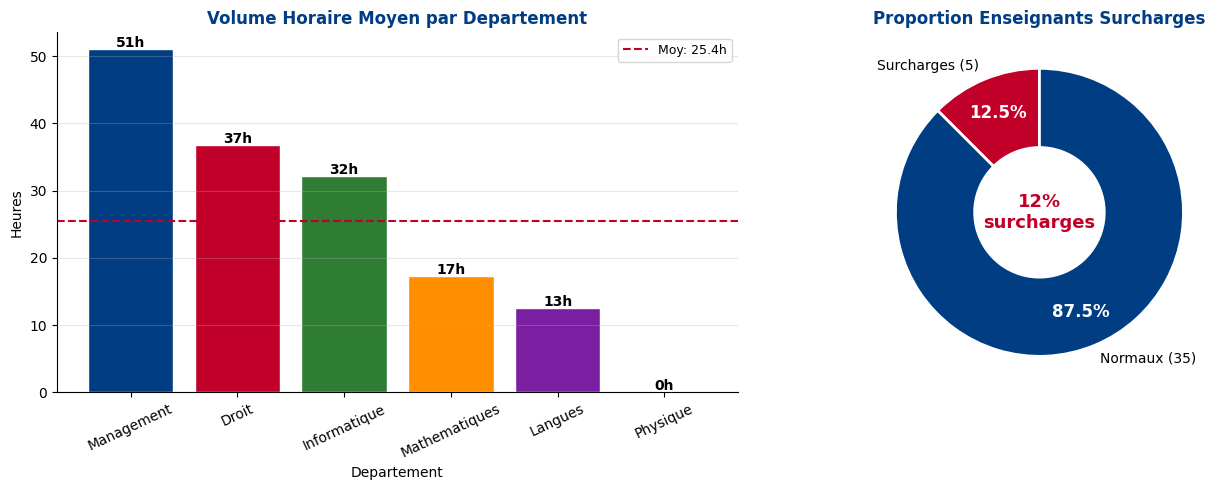

Sauvegarde: ax2_dept_surcharge.png


In [10]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
dept_vol=df_vol.groupby('Departement')['Volume_H'].mean().sort_values(ascending=False)
axes[0].bar(dept_vol.index,dept_vol.values,color=COLORS[:len(dept_vol)],edgecolor='white')
for i,v in enumerate(dept_vol.values):
    axes[0].text(i,v+0.3,f'{v:.0f}h',ha='center',fontweight='bold',fontsize=10)
axes[0].axhline(moy_vol,color=RED,linestyle='--',linewidth=1.5,label=f'Moy: {moy_vol:.1f}h')
axes[0].set_title('Volume Horaire Moyen par Departement',fontsize=12,fontweight='bold',color=BLUE)
axes[0].set_xlabel('Departement'); axes[0].set_ylabel('Heures'); axes[0].tick_params(axis='x',rotation=25)
axes[0].legend(fontsize=9); axes[0].grid(axis='y',alpha=0.3)

nb_norm=len(df_vol)-nb_surcharge
wedges,texts,autos=axes[1].pie([nb_surcharge,nb_norm],
    labels=[f'Surcharges ({nb_surcharge})',f'Normaux ({nb_norm})'],
    autopct='%1.1f%%',colors=[RED,BLUE],startangle=90,pctdistance=0.75,
    wedgeprops=dict(width=0.55,edgecolor='white',linewidth=2))
for at in autos: at.set_fontsize(12); at.set_fontweight('bold'); at.set_color('white')
axes[1].text(0,0,f'{nb_surcharge/len(df_vol)*100:.0f}%\nsurcharges',ha='center',va='center',fontsize=13,fontweight='bold',color=RED)
axes[1].set_title('Proportion Enseignants Surcharges',fontsize=12,fontweight='bold',color=BLUE)
plt.tight_layout(); plt.savefig('ax2_dept_surcharge.png',dpi=150,bbox_inches='tight'); plt.show()
print('Sauvegarde: ax2_dept_surcharge.png')

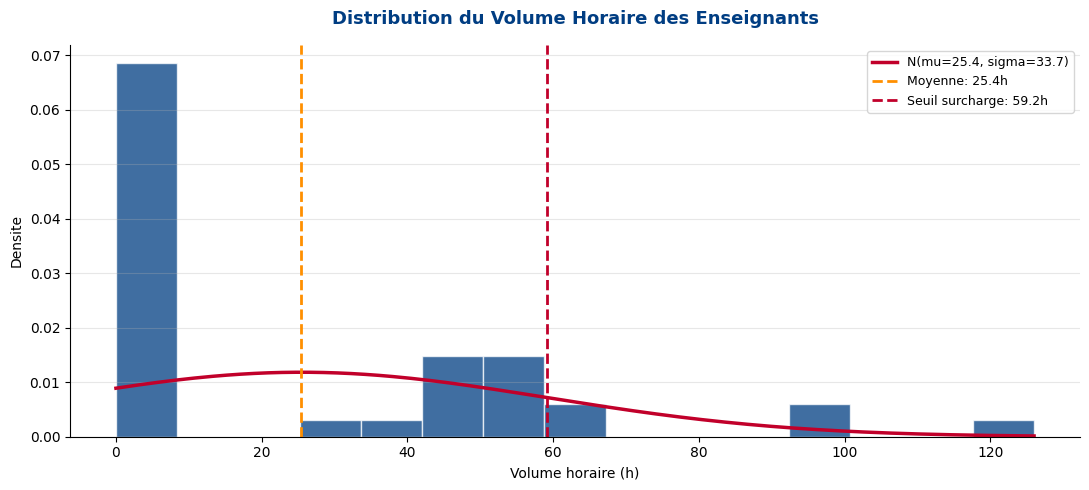

Sauvegarde: ax2_distribution.png


In [11]:
fig,ax=plt.subplots(figsize=(11,5))
ax.hist(df_vol['Volume_H'],bins=15,color=BLUE,alpha=0.75,edgecolor='white',density=True)
mu,sigma=df_vol['Volume_H'].mean(),df_vol['Volume_H'].std()
x=np.linspace(df_vol['Volume_H'].min(),df_vol['Volume_H'].max(),200)
ax.plot(x,stats.norm.pdf(x,mu,sigma),color=RED,linewidth=2.5,label=f'N(mu={mu:.1f}, sigma={sigma:.1f})')
ax.axvline(mu,color=ORANGE,linestyle='--',linewidth=2,label=f'Moyenne: {mu:.1f}h')
ax.axvline(seuil,color=RED,linestyle='--',linewidth=2,label=f'Seuil surcharge: {seuil:.1f}h')
ax.set_title('Distribution du Volume Horaire des Enseignants',fontsize=13,fontweight='bold',color=BLUE,pad=15)
ax.set_xlabel('Volume horaire (h)'); ax.set_ylabel('Densite'); ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig('ax2_distribution.png',dpi=150,bbox_inches='tight'); plt.show()
print('Sauvegarde: ax2_distribution.png')

---
# ⚠️ AXE 3 — Taux de Conflits
**Formules :**
- `Taux resolution = Conflits resolus / Total x 100`
- `Taux non resolution = Conflits non resolus / Total x 100`

In [12]:
total_conf=len(df_conf)
nb_resolus=int(df_conf['Resolu'].sum())
nb_non_resolus=total_conf-nb_resolus
taux_reso=nb_resolus/total_conf*100
taux_non_reso=nb_non_resolus/total_conf*100
print('=== CONFLITS ===')
print(f'Total               : {total_conf}')
print(f'Resolus             : {nb_resolus} ({taux_reso:.1f}%)')
print(f'Non resolus         : {nb_non_resolus} ({taux_non_reso:.1f}%)')
print(f'\nRepartition types:')
print(df_conf['Type_Conflit'].value_counts().to_string())
print(f'\nJour + conflictuel  : {df_conf["Jour_Semaine"].value_counts().idxmax()}')
print(f'Creneau + conflictuel: {df_conf["Heure_Debut"].value_counts().idxmax()}')

=== CONFLITS ===
Total               : 80
Resolus             : 55 (68.8%)
Non resolus         : 25 (31.2%)

Repartition types:
Type_Conflit
Double reservation salle      21
Salle indisponible            16
Conflit horaire enseignant    16
Chevauchement de creneaux     15
Capacite insuffisante         12

Jour + conflictuel  : Vendredi
Creneau + conflictuel: 10:15


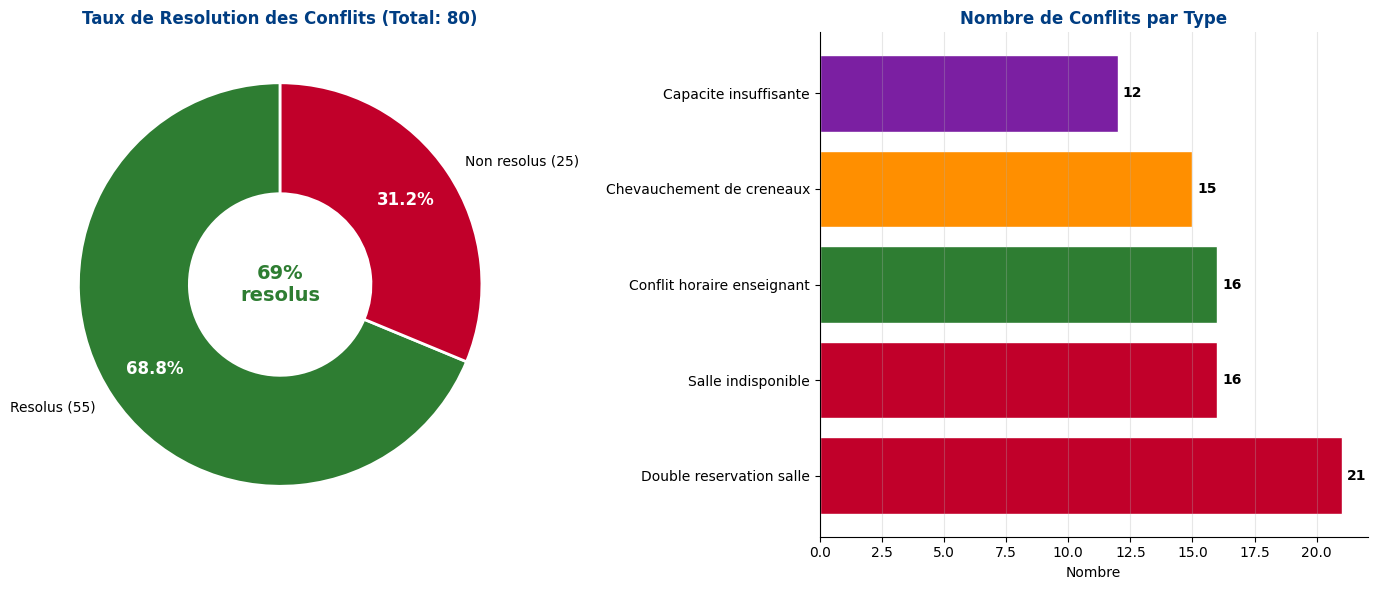

Sauvegarde: ax3_donut_types.png


In [13]:
fig,axes=plt.subplots(1,2,figsize=(14,6))
wedges,texts,autos=axes[0].pie([nb_resolus,nb_non_resolus],
    labels=[f'Resolus ({nb_resolus})',f'Non resolus ({nb_non_resolus})'],
    autopct='%1.1f%%',colors=[GREEN,RED],startangle=90,pctdistance=0.75,
    wedgeprops=dict(width=0.55,edgecolor='white',linewidth=2))
for at in autos: at.set_fontsize(12); at.set_fontweight('bold'); at.set_color('white')
axes[0].text(0,0,f'{taux_reso:.0f}%\nresolus',ha='center',va='center',fontsize=14,fontweight='bold',color=GREEN)
axes[0].set_title(f'Taux de Resolution des Conflits (Total: {total_conf})',fontsize=12,fontweight='bold',color=BLUE)

type_conf=df_conf['Type_Conflit'].value_counts()
axes[1].barh(type_conf.index,type_conf.values,color=[RED if i==0 else COLORS[i] for i in range(len(type_conf))],edgecolor='white')
for i,v in enumerate(type_conf.values):
    axes[1].text(v+0.2,i,str(v),va='center',fontweight='bold',fontsize=10)
axes[1].set_title('Nombre de Conflits par Type',fontsize=12,fontweight='bold',color=BLUE)
axes[1].set_xlabel('Nombre'); axes[1].grid(axis='x',alpha=0.3)
plt.tight_layout(); plt.savefig('ax3_donut_types.png',dpi=150,bbox_inches='tight'); plt.show()
print('Sauvegarde: ax3_donut_types.png')

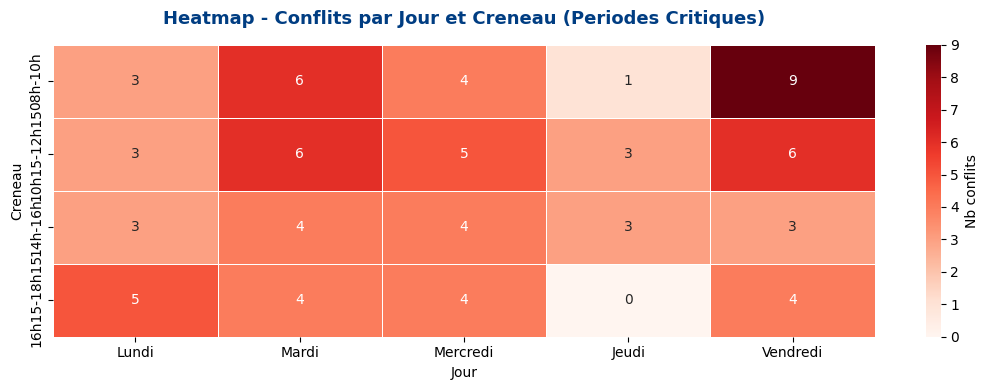

Sauvegarde: ax3_heatmap.png


In [14]:
conf_heat=df_conf.groupby(['Jour_Semaine','Heure_Debut']).size().reset_index(name='Nb')
conf_pivot=conf_heat.pivot(index='Heure_Debut',columns='Jour_Semaine',values='Nb').fillna(0)
cols_c=[j for j in JOURS_ORDER if j in conf_pivot.columns]
rows_c=[c for c in CRENEAUX_ORDER if c in conf_pivot.index]
conf_pivot=conf_pivot.reindex(index=rows_c,columns=cols_c)
conf_pivot.index=[LABELS_C.get(i,i) for i in conf_pivot.index]

fig,ax=plt.subplots(figsize=(11,4))
sns.heatmap(conf_pivot,annot=True,fmt='.0f',cmap='Reds',linewidths=0.5,linecolor='white',ax=ax,
    cbar_kws={'label':'Nb conflits'})
ax.set_title('Heatmap - Conflits par Jour et Creneau (Periodes Critiques)',fontsize=13,fontweight='bold',color=BLUE,pad=15)
ax.set_xlabel('Jour'); ax.set_ylabel('Creneau')
plt.tight_layout(); plt.savefig('ax3_heatmap.png',dpi=150,bbox_inches='tight'); plt.show()
print('Sauvegarde: ax3_heatmap.png')

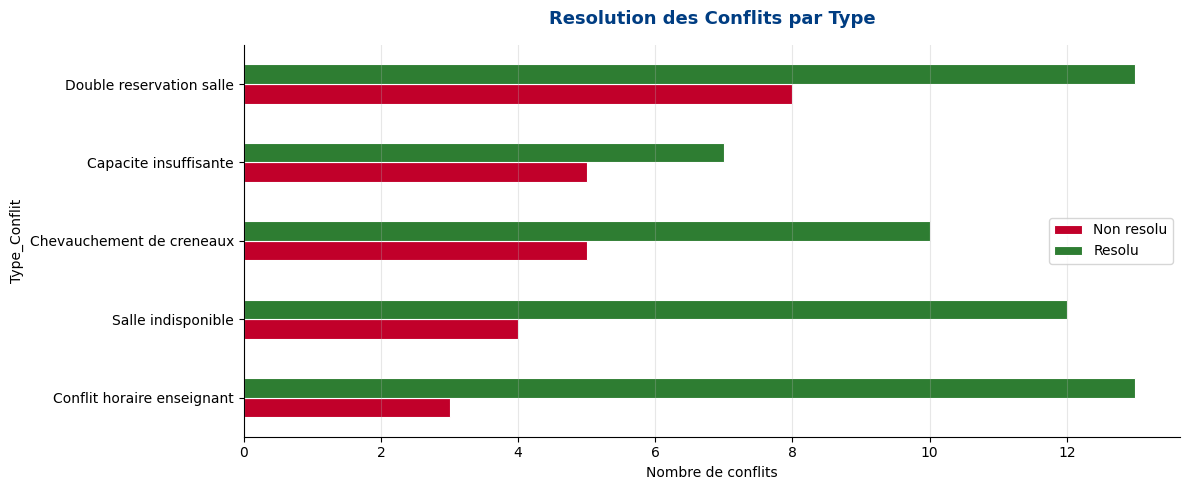

Sauvegarde: ax3_resolution_type.png


In [15]:
conf_tr=df_conf.groupby(['Type_Conflit','Resolu']).size().unstack(fill_value=0)
conf_tr.columns=['Non resolu','Resolu']
conf_tr=conf_tr.sort_values('Non resolu',ascending=True)
fig,ax=plt.subplots(figsize=(12,5))
conf_tr.plot(kind='barh',ax=ax,color=[RED,GREEN],edgecolor='white',linewidth=0.8)
ax.set_title('Resolution des Conflits par Type',fontsize=13,fontweight='bold',color=BLUE,pad=15)
ax.set_xlabel('Nombre de conflits'); ax.grid(axis='x',alpha=0.3); ax.legend(fontsize=10)
plt.tight_layout(); plt.savefig('ax3_resolution_type.png',dpi=150,bbox_inches='tight'); plt.show()
print('Sauvegarde: ax3_resolution_type.png')

---
# 📊 DASHBOARD FINAL — Les 3 Axes en 1 Vue

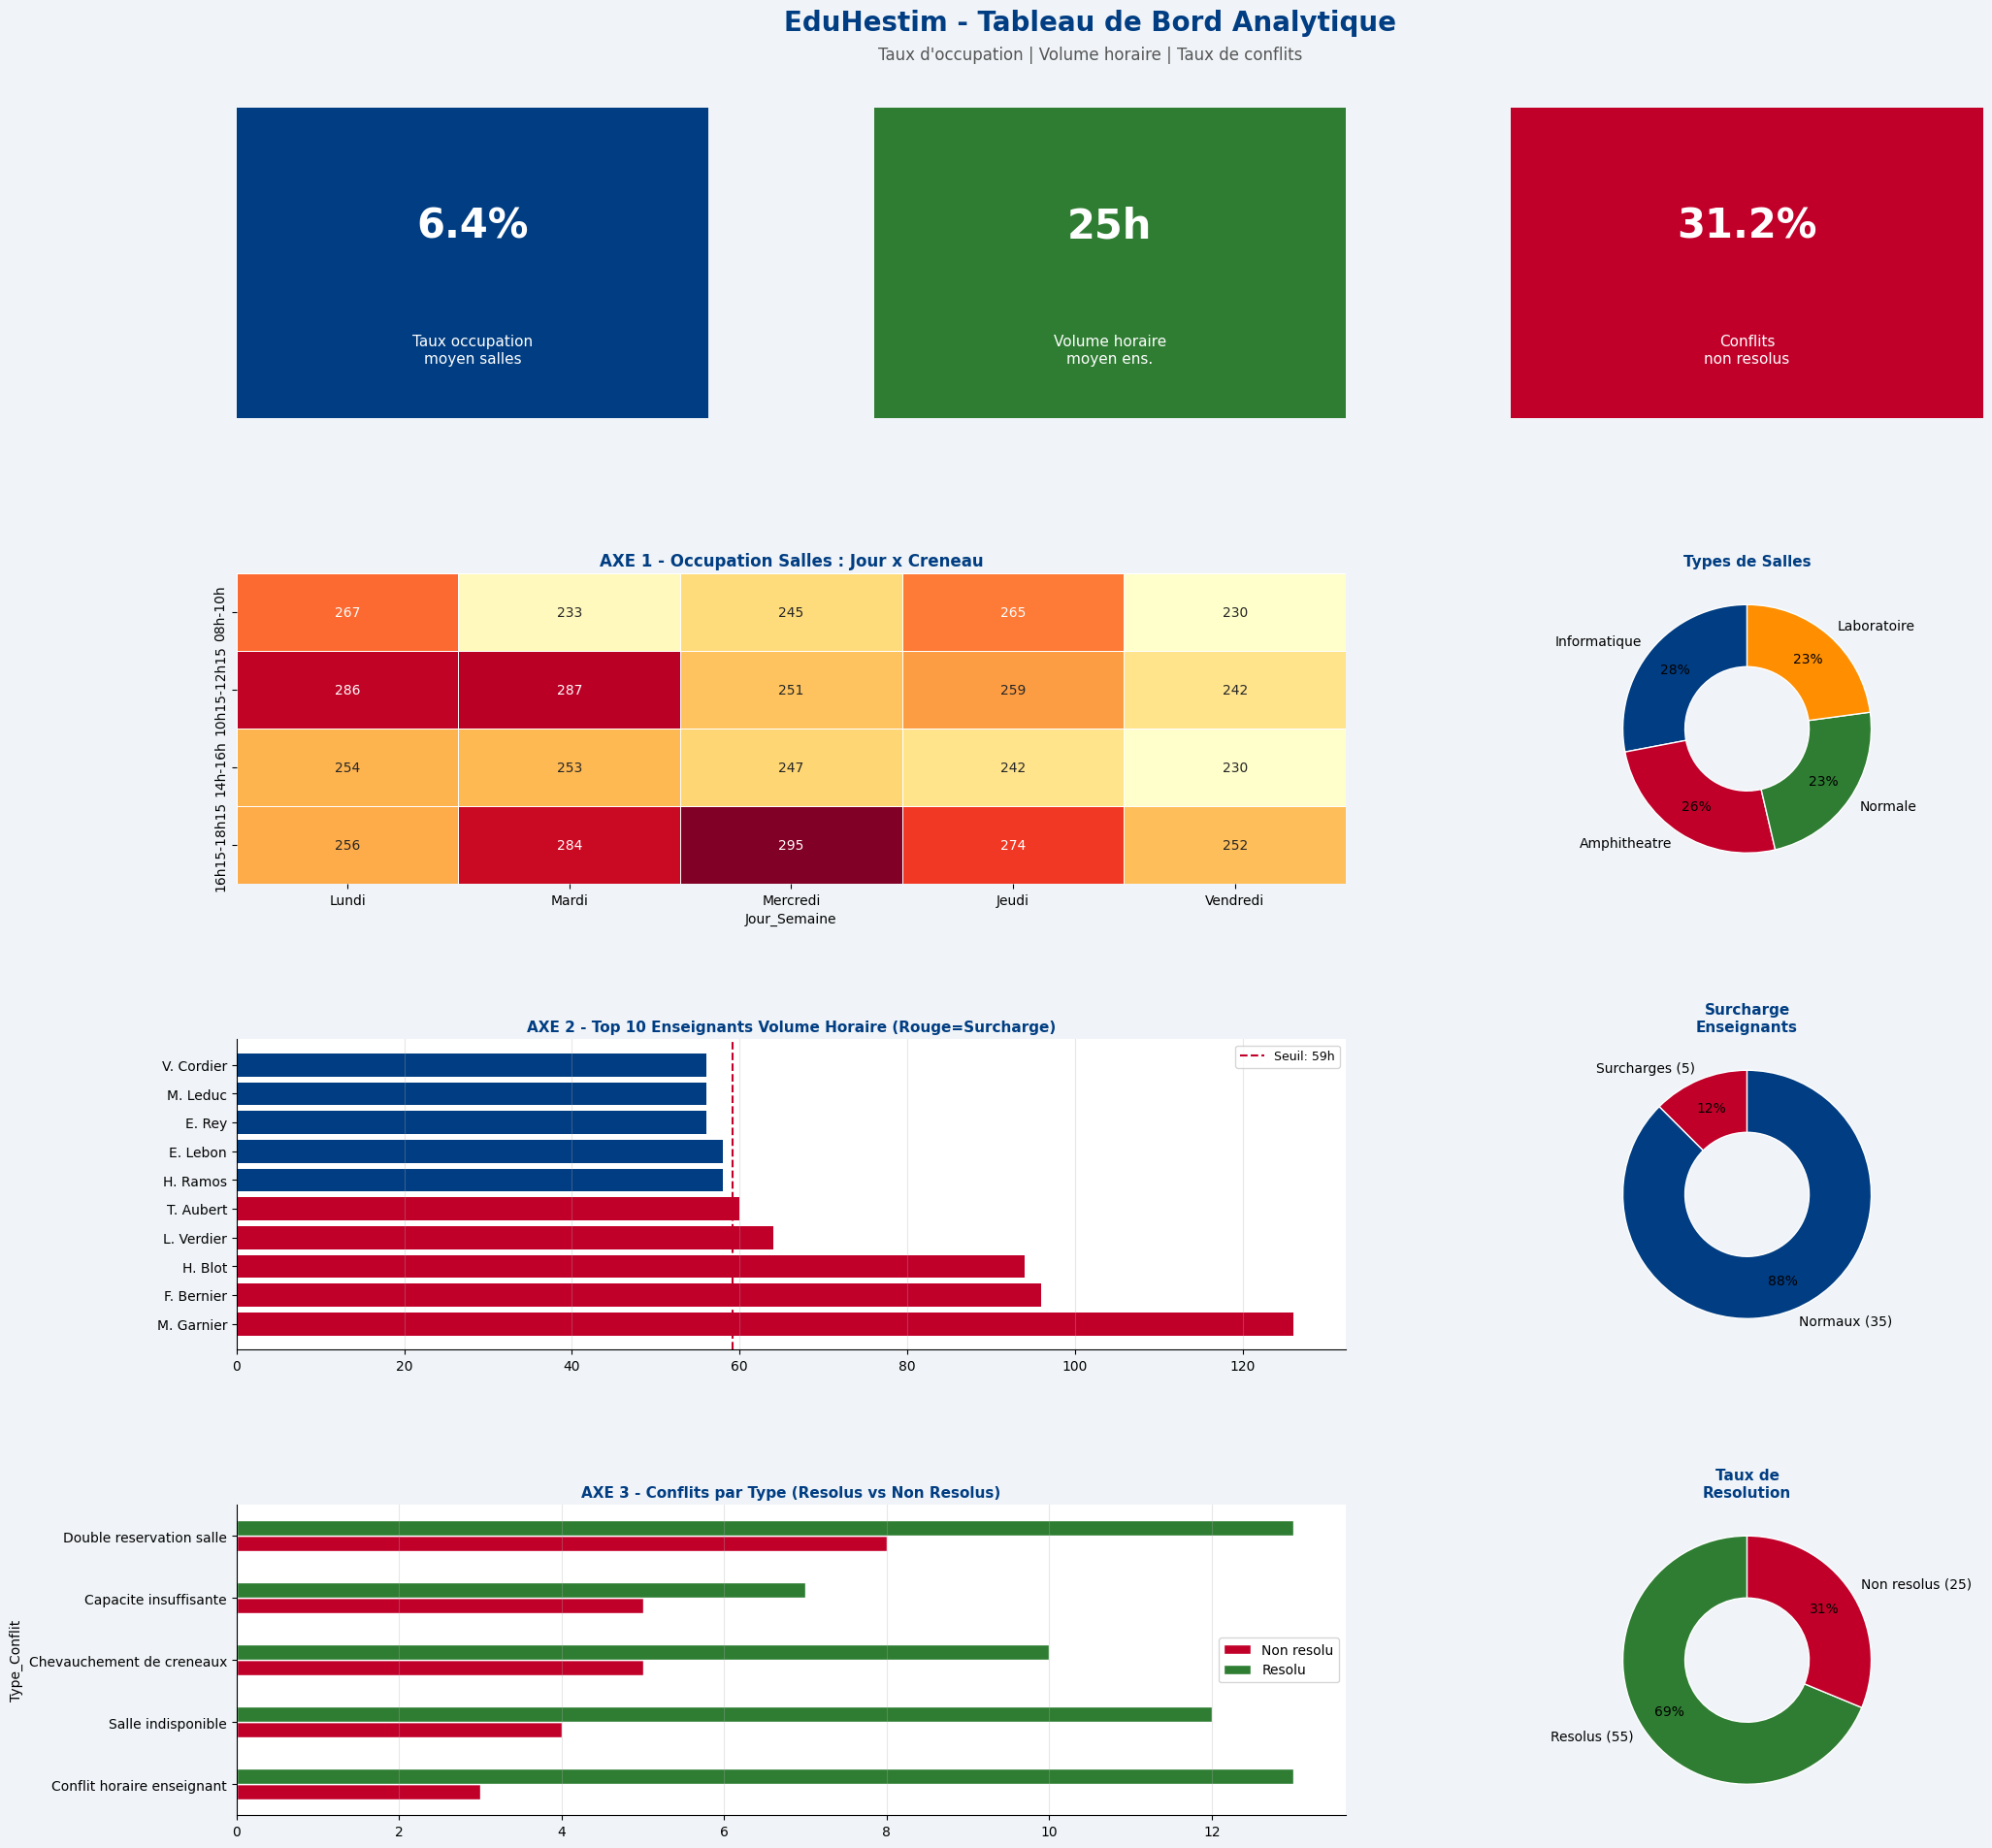

Dashboard sauvegarde: eduhestim_dashboard.png


In [16]:
fig=plt.figure(figsize=(20,20))
fig.patch.set_facecolor('#f0f4f8')
gs=fig.add_gridspec(4,3,hspace=0.5,wspace=0.35,left=0.06,right=0.96,top=0.92,bottom=0.04)
fig.text(0.5,0.96,'EduHestim - Tableau de Bord Analytique',ha='center',fontsize=20,fontweight='bold',color=BLUE)
fig.text(0.5,0.945,"Taux d'occupation | Volume horaire | Taux de conflits",ha='center',fontsize=12,color='#555')

kpis=[(f"{df_occ['Taux_Occupation'].mean():.1f}%","Taux occupation\nmoyen salles",BLUE),
      (f"{moy_vol:.0f}h","Volume horaire\nmoyen ens.",GREEN),
      (f"{taux_non_reso:.1f}%","Conflits\nnon resolus",RED)]
for i,(val,label,col) in enumerate(kpis):
    ax=fig.add_subplot(gs[0,i])
    ax.set_facecolor(col)
    ax.text(0.5,0.62,val,ha='center',va='center',fontsize=30,fontweight='bold',color='white',transform=ax.transAxes)
    ax.text(0.5,0.22,label,ha='center',va='center',fontsize=11,color='white',transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

ax_h=fig.add_subplot(gs[1,:2])
sns.heatmap(heat_pivot,annot=True,fmt='.0f',cmap='YlOrRd',linewidths=0.4,linecolor='white',ax=ax_h,cbar=False)
ax_h.set_title('AXE 1 - Occupation Salles : Jour x Creneau',fontsize=12,fontweight='bold',color=BLUE)

ax_d1=fig.add_subplot(gs[1,2])
ax_d1.pie(type_counts.values,labels=type_counts.index,autopct='%1.0f%%',colors=COLORS[:len(type_counts)],
    startangle=90,pctdistance=0.75,wedgeprops=dict(width=0.5,edgecolor='white'))
ax_d1.set_title('Types de Salles',fontsize=11,fontweight='bold',color=BLUE)

ax_e=fig.add_subplot(gs[2,:2])
top10e=df_vol.nlargest(10,'Volume_H')
ax_e.barh(top10e['Nom_Complet'],top10e['Volume_H'],color=[RED if s else BLUE for s in top10e['Surcharge']])
ax_e.axvline(seuil,color=RED,linestyle='--',linewidth=1.5,label=f'Seuil: {seuil:.0f}h')
ax_e.set_title('AXE 2 - Top 10 Enseignants Volume Horaire (Rouge=Surcharge)',fontsize=11,fontweight='bold',color=BLUE)
ax_e.legend(fontsize=9); ax_e.grid(axis='x',alpha=0.3)

ax_d2=fig.add_subplot(gs[2,2])
ax_d2.pie([nb_surcharge,len(df_vol)-nb_surcharge],
    labels=[f'Surcharges ({nb_surcharge})',f'Normaux ({len(df_vol)-nb_surcharge})'],
    autopct='%1.0f%%',colors=[RED,BLUE],startangle=90,pctdistance=0.75,
    wedgeprops=dict(width=0.5,edgecolor='white'))
ax_d2.set_title('Surcharge\nEnseignants',fontsize=11,fontweight='bold',color=BLUE)

ax_c=fig.add_subplot(gs[3,:2])
conf_tr.plot(kind='barh',ax=ax_c,color=[RED,GREEN],edgecolor='white')
ax_c.set_title('AXE 3 - Conflits par Type (Resolus vs Non Resolus)',fontsize=11,fontweight='bold',color=BLUE)
ax_c.grid(axis='x',alpha=0.3)

ax_d3=fig.add_subplot(gs[3,2])
ax_d3.pie([nb_resolus,nb_non_resolus],
    labels=[f'Resolus ({nb_resolus})',f'Non resolus ({nb_non_resolus})'],
    autopct='%1.0f%%',colors=[GREEN,RED],startangle=90,pctdistance=0.75,
    wedgeprops=dict(width=0.5,edgecolor='white'))
ax_d3.set_title('Taux de\nResolution',fontsize=11,fontweight='bold',color=BLUE)

plt.savefig('eduhestim_dashboard.png',dpi=150,bbox_inches='tight',facecolor='#f0f4f8')
plt.show()
print('Dashboard sauvegarde: eduhestim_dashboard.png')

---
# 📝 SYNTHESE & RECOMMANDATIONS

In [17]:
salle_max_nom=df_occ.loc[df_occ['Taux_Occupation'].idxmax(),'Nom_Salle']
salle_max_taux=df_occ['Taux_Occupation'].max()
ens_top3=df_vol[df_vol['Surcharge']].nlargest(3,'Volume_H')[['Nom_Complet','Volume_H','Departement']]
type_conf_max=df_conf['Type_Conflit'].value_counts().idxmax()
jour_conf_max=df_conf['Jour_Semaine'].value_counts().idxmax()

print('='*65)
print('         SYNTHESE ANALYTIQUE - EduHestim')
print('='*65)
print(f'\nAXE 1 - TAUX OCCUPATION SALLES')
print(f'  Taux moyen global         : {df_occ["Taux_Occupation"].mean():.1f}%')
print(f'  Salle la plus occupee     : {salle_max_nom} ({salle_max_taux:.1f}%)')
print(f'  Salles en surcharge       : {(df_occ["Taux_Occupation"]>moy_occ*1.3).sum()}')
print(f'  Type de salle + demande   : {type_counts.idxmax()}')
print(f'\nAXE 2 - VOLUME HORAIRE ENSEIGNANTS')
print(f'  Volume moyen              : {moy_vol:.1f}h')
print(f'  Seuil surcharge           : {seuil:.1f}h')
print(f'  Nb surchargés             : {nb_surcharge}/{len(df_vol)} ({nb_surcharge/len(df_vol)*100:.1f}%)')
print(f'  Top 3 surchargés:')
for _,row in ens_top3.iterrows():
    print(f'    -> {row["Nom_Complet"]:20s} {int(row["Volume_H"])}h  ({row["Departement"]})')
print(f'\nAXE 3 - TAUX DE CONFLITS')
print(f'  Total conflits            : {total_conf}')
print(f'  Taux resolution           : {taux_reso:.1f}%')
print(f'  Taux non resolus          : {taux_non_reso:.1f}%')
print(f'  Type dominant             : {type_conf_max}')
print(f'  Jour le + conflictuel     : {jour_conf_max}')
print(f'\nRECOMMANDATIONS')
print(f'  1. Redistribuer les reservations depuis {salle_max_nom} vers salles sous-utilisees')
print(f'  2. Alleger la charge des {nb_surcharge} enseignants depassant {seuil:.0f}h')
print(f'  3. Prioriser resolution des conflits de type: {type_conf_max}')
print(f'  4. Renforcer surveillance le {jour_conf_max} (jour le + conflictuel)')
print('='*65)

         SYNTHESE ANALYTIQUE - EduHestim

AXE 1 - TAUX OCCUPATION SALLES
  Taux moyen global         : 6.4%
  Salle la plus occupee     : Norm-54 (11.6%)
  Salles en surcharge       : 34
  Type de salle + demande   : Informatique

AXE 2 - VOLUME HORAIRE ENSEIGNANTS
  Volume moyen              : 25.4h
  Seuil surcharge           : 59.2h
  Nb surchargés             : 5/40 (12.5%)
  Top 3 surchargés:
    -> M. Garnier           126h  (Informatique)
    -> F. Bernier           96h  (Informatique)
    -> H. Blot              94h  (Droit)

AXE 3 - TAUX DE CONFLITS
  Total conflits            : 80
  Taux resolution           : 68.8%
  Taux non resolus          : 31.2%
  Type dominant             : Double reservation salle
  Jour le + conflictuel     : Vendredi

RECOMMANDATIONS
  1. Redistribuer les reservations depuis Norm-54 vers salles sous-utilisees
  2. Alleger la charge des 5 enseignants depassant 59h
  3. Prioriser resolution des conflits de type: Double reservation salle
  4. Renforcer